# DEPM Variants — No Leakage | Train & Save for FastAPI

**Models trained:**
- 5 DEPM variants (DL + XGBoost hybrid): DNN, LSTM, BiLSTM, GRU, BiGRU
- 5 Standalone DL models: DNN, LSTM, BiLSTM, GRU, BiGRU

**No leakage:** `Global_intensity` and all GAP-derived features removed.

## 1. Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import time, json, os, joblib, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report)
from xgboost import XGBClassifier
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.dpi'] = 110
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Paths
if os.path.exists('/kaggle/input'):
    DATA_PATH = '/kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt'
    SAVE_DIR = '/kaggle/working/models'
else:
    DATA_PATH = '../data/household_power_consumption.txt'
    SAVE_DIR = '../models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Data: {DATA_PATH}")
print(f"Save: {SAVE_DIR}")

Device: cuda
GPU: Tesla T4
Data: /kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt
Save: /kaggle/working/models


## 2. Data Loading & Preprocessing

In [2]:
df = pd.read_csv(DATA_PATH, sep=';', low_memory=False, na_values=['?'])
num_cols = ['Global_active_power','Global_reactive_power','Voltage',
            'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
for c in num_cols: df[c] = pd.to_numeric(df[c], errors='coerce')
df['Datetime'] = pd.to_datetime(df['Date']+' '+df['Time'], format='%d/%m/%Y %H:%M:%S')
df.drop(columns=['Date','Time'], inplace=True)
df.set_index('Datetime', inplace=True)
print(f"Raw: {df.shape}")

# Median imputation
for c in num_cols: df[c].fillna(df[c].median(), inplace=True)

# IQR outlier removal
for c in num_cols:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[c] >= Q1-1.5*IQR) & (df[c] <= Q3+1.5*IQR)]
print(f"After IQR: {df.shape}")

# Hourly resampling
df_h = df.resample('1h').mean().dropna()
threshold = df_h['Global_active_power'].median()
df_h['Label'] = (df_h['Global_active_power'] > threshold).astype(int)
print(f"Hourly: {df_h.shape}, Threshold: {threshold:.4f} kW, Balance: {df_h['Label'].mean():.2%} High")

Raw: (2075259, 7)
After IQR: (1739080, 7)
Hourly: (33528, 8), Threshold: 0.6121 kW, Balance: 50.00% High


## 3. Feature Engineering (No Leakage)

In [3]:
df_h['Hour'] = df_h.index.hour
df_h['DayOfWeek'] = df_h.index.dayofweek
df_h['Month'] = df_h.index.month
df_h['Season'] = df_h['Month'].map({12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})
df_h['IsWeekend'] = (df_h.index.dayofweek >= 5).astype(int)
df_h['SubTotal'] = df_h[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].sum(axis=1)
df_h['SubRatio_1'] = df_h['Sub_metering_1'] / (df_h['SubTotal'] + 1e-6)
df_h['SubRatio_2'] = df_h['Sub_metering_2'] / (df_h['SubTotal'] + 1e-6)
df_h['SubRatio_3'] = df_h['Sub_metering_3'] / (df_h['SubTotal'] + 1e-6)
holidays = pd.to_datetime(['2007-01-01','2007-05-01','2007-07-14','2007-11-01','2007-12-25',
    '2008-01-01','2008-05-01','2008-07-14','2008-11-01','2008-12-25',
    '2009-01-01','2009-05-01','2009-07-14','2009-11-01','2009-12-25',
    '2010-01-01','2010-05-01','2010-07-14','2010-11-01','2010-12-25'])
df_h['IsHoliday'] = df_h.index.normalize().isin(holidays).astype(int)
df_h.dropna(inplace=True)

exclude = ['Global_active_power', 'Global_intensity', 'Label']
feature_cols = [c for c in df_h.columns if c not in exclude]
print(f"Features ({len(feature_cols)}): {feature_cols}")

X = df_h[feature_cols].values; y = df_h['Label'].values
scaler = StandardScaler(); X_sc = scaler.fit_transform(X)
pca = PCA(n_components=0.95, random_state=42); X_pca = pca.fit_transform(X_sc)
print(f"PCA: {X_sc.shape[1]} -> {X_pca.shape[1]} components")

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Save preprocessing artifacts
joblib.dump(scaler, f'{SAVE_DIR}/scaler.pkl')
joblib.dump(pca, f'{SAVE_DIR}/pca.pkl')
json.dump({'features': feature_cols, 'threshold': float(threshold)}, open(f'{SAVE_DIR}/config.json','w'))
print("Saved: scaler.pkl, pca.pkl, config.json")

Features (15): ['Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Hour', 'DayOfWeek', 'Month', 'Season', 'IsWeekend', 'SubTotal', 'SubRatio_1', 'SubRatio_2', 'SubRatio_3', 'IsHoliday']
PCA: 15 -> 10 components
Train: (26822, 10) | Test: (6706, 10)
Saved: scaler.pkl, pca.pkl, config.json


## 4. Cascaded ResNet Feature Extraction

In [4]:
class ResBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,d), nn.BatchNorm1d(d), nn.ReLU(), nn.Linear(d,d), nn.BatchNorm1d(d))
        self.act = nn.ReLU()
    def forward(self, x): return self.act(self.net(x) + x)

class CascadedResNet(nn.Module):
    def __init__(self, inp, hid=128, blocks=4, out=32):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(inp, hid), nn.BatchNorm1d(hid), nn.ReLU())
        self.blocks = nn.Sequential(*[ResBlock(hid) for _ in range(blocks)])
        self.fc = nn.Linear(hid, out)
    def forward(self, x): return self.fc(self.blocks(self.proj(x)))

resnet = CascadedResNet(X_train.shape[1]).to(device)
dec = nn.Linear(32, X_train.shape[1]).to(device)
opt_ae = optim.Adam(list(resnet.parameters())+list(dec.parameters()), lr=1e-3)

# Keep tensors on CPU for DataLoader — move to GPU inside loop
tr_cpu = torch.FloatTensor(X_train)
te_cpu = torch.FloatTensor(X_test)
loader = DataLoader(TensorDataset(tr_cpu, tr_cpu), batch_size=256, shuffle=True)

print("Training Cascaded ResNet...")
for ep in range(30):
    for xb, _ in loader:
        xb = xb.to(device)
        z = resnet(xb); loss = nn.MSELoss()(dec(z), xb)
        opt_ae.zero_grad(); loss.backward(); opt_ae.step()
    if (ep+1)%10==0: print(f"  Epoch {ep+1} | Loss: {loss.item():.6f}")

resnet.eval()
with torch.no_grad():
    Z_tr = resnet(tr_cpu.to(device)).cpu().numpy()
    Z_te = resnet(te_cpu.to(device)).cpu().numpy()
X_tr = np.hstack([X_train, Z_tr]); X_te = np.hstack([X_test, Z_te])
print(f"Combined: PCA({X_train.shape[1]}) + ResNet(32) = {X_tr.shape[1]}")
torch.save(resnet.state_dict(), f'{SAVE_DIR}/resnet.pt')

Training Cascaded ResNet...
  Epoch 10 | Loss: 0.011234
  Epoch 20 | Loss: 0.013561
  Epoch 30 | Loss: 0.011338
Combined: PCA(10) + ResNet(32) = 42


## 5. Model Architectures

In [5]:
class DNN(nn.Module):
    def __init__(self, inp, hid=128, layers=5, drop=0.3):
        super().__init__()
        mods = [nn.Linear(inp, hid), nn.BatchNorm1d(hid), nn.ReLU(), nn.Dropout(drop)]
        for _ in range(layers-2):
            mods += [nn.Linear(hid, hid), nn.BatchNorm1d(hid), nn.ReLU(), nn.Dropout(drop)]
        mods += [nn.Linear(hid, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*mods)
    def forward(self, x): return self.net(x).squeeze(-1)
    def features(self, x):
        for m in list(self.net.children())[:-2]: x = m(x)
        return x

class RNNModel(nn.Module):
    def __init__(self, inp, hid=128, rnn_type='lstm', bidir=False, drop=0.3):
        super().__init__()
        RNN = {'lstm': nn.LSTM, 'gru': nn.GRU}[rnn_type]
        self.rnn = RNN(1, hid, num_layers=2, batch_first=True, dropout=drop, bidirectional=bidir)
        mult = 2 if bidir else 1
        self.head = nn.Sequential(nn.Linear(hid*mult, 64), nn.ReLU(), nn.Dropout(drop),
                                  nn.Linear(64, 1), nn.Sigmoid())
        self.feat_layer = nn.Sequential(nn.Linear(hid*mult, 64), nn.ReLU())
    def forward(self, x):
        x = x.unsqueeze(-1)  # (B, seq, 1)
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :]).squeeze(-1)
    def features(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.rnn(x)
        return self.feat_layer(out[:, -1, :])

def make_model(name, inp):
    if name == 'DNN': return DNN(inp)
    elif name == 'LSTM': return RNNModel(inp, rnn_type='lstm', bidir=False)
    elif name == 'BiLSTM': return RNNModel(inp, rnn_type='lstm', bidir=True)
    elif name == 'GRU': return RNNModel(inp, rnn_type='gru', bidir=False)
    elif name == 'BiGRU': return RNNModel(inp, rnn_type='gru', bidir=True)

## 6. Training Functions

In [6]:
def train_model(model, X_tr, y_tr, epochs=50, bs=64, lr=1e-3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit = nn.BCELoss()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)),
                        batch_size=bs, shuffle=True)
    t0 = time.time()
    for ep in range(epochs):
        model.train(); ep_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
            ep_loss += loss.item()*xb.size(0)
        sched.step(ep_loss/len(X_tr))
        if (ep+1)%10==0: print(f"    Ep {ep+1:02d} loss={ep_loss/len(X_tr):.4f}")
    return time.time()-t0

def evaluate(model, X_te, y_te):
    model.eval()
    with torch.no_grad():
        probs = model(torch.FloatTensor(X_te).to(device)).cpu().numpy()
    preds = (probs>0.5).astype(int)
    return preds, probs, {
        'Accuracy': accuracy_score(y_te, preds), 'Precision': precision_score(y_te, preds),
        'Recall': recall_score(y_te, preds), 'F1-Score': f1_score(y_te, preds),
        'AUC': roc_auc_score(y_te, probs)}

def extract_feats(model, X, batch_size=512):
    """Extract features in batches to avoid GPU OOM."""
    model.eval()
    feats = []
    for i in range(0, len(X), batch_size):
        xb = torch.FloatTensor(X[i:i+batch_size]).to(device)
        with torch.no_grad():
            fb = model.features(xb).cpu().numpy()
        feats.append(fb)
        del xb  # free GPU memory
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return np.vstack(feats)

## 7. Train Standalone Models

In [7]:
arch_names = ['DNN', 'LSTM', 'BiLSTM', 'GRU', 'BiGRU']
standalone_results = {}
standalone_preds = {}
standalone_probs = {}
trained_models = {}  # Store for DEPM reuse

print('='*60)
print('  STANDALONE DL MODELS')
print('='*60)
for name in arch_names:
    print(f'\n>> {name}')
    model = make_model(name, X_tr.shape[1])
    elapsed = train_model(model, X_tr, y_train, epochs=50, bs=64)
    preds, probs, metrics = evaluate(model, X_te, y_test)
    metrics['Time'] = f'{elapsed:.1f}s'
    standalone_results[name] = metrics
    standalone_preds[name] = preds
    standalone_probs[name] = probs
    trained_models[name] = model  # Keep for DEPM
    torch.save(model.state_dict(), f'{SAVE_DIR}/standalone_{name.lower()}.pt')
    print(f'   Acc={metrics["Accuracy"]:.4f} F1={metrics["F1-Score"]:.4f} AUC={metrics["AUC"]:.4f} ({elapsed:.1f}s)')

print('\nStandalone models saved!')

  STANDALONE DL MODELS

>> DNN
    Ep 10 loss=0.2529
    Ep 20 loss=0.2465
    Ep 30 loss=0.2422
    Ep 40 loss=0.2378
    Ep 50 loss=0.2352
   Acc=0.8953 F1=0.8925 AUC=0.9599 (73.2s)

>> LSTM
    Ep 10 loss=0.2623
    Ep 20 loss=0.2488
    Ep 30 loss=0.2391
    Ep 40 loss=0.2328
    Ep 50 loss=0.2262
   Acc=0.8904 F1=0.8849 AUC=0.9536 (73.0s)

>> BiLSTM
    Ep 10 loss=0.2626
    Ep 20 loss=0.2513
    Ep 30 loss=0.2421
    Ep 40 loss=0.2362
    Ep 50 loss=0.2292
   Acc=0.8885 F1=0.8817 AUC=0.9532 (133.5s)

>> GRU
    Ep 10 loss=0.2595
    Ep 20 loss=0.2424
    Ep 30 loss=0.2265
    Ep 40 loss=0.2170
    Ep 50 loss=0.2059
   Acc=0.8874 F1=0.8819 AUC=0.9506 (69.5s)

>> BiGRU
    Ep 10 loss=0.2532
    Ep 20 loss=0.2332
    Ep 30 loss=0.2207
    Ep 40 loss=0.2040
    Ep 50 loss=0.1891
   Acc=0.8870 F1=0.8813 AUC=0.9491 (94.0s)

Standalone models saved!


## 8. Train DEPM Variants (DL + XGBoost Hybrid)

In [8]:
depm_results = {}
depm_preds = {}
depm_probs = {}

print('='*60)
print('  DEPM VARIANTS (Reusing Standalone DL → XGBoost)')
print('='*60)
for name in arch_names:
    print(f'\n>> DEPM-{name}')
    # Reuse the already-trained standalone model
    model = trained_models[name]
    
    # Extract features in batches (avoids OOM)
    print('   Extracting DL features (batched)...')
    feat_tr = extract_feats(model, X_tr, batch_size=256)
    feat_te = extract_feats(model, X_te, batch_size=256)
    
    # Combine: original features + DL features
    X_hyb_tr = np.hstack([X_tr, feat_tr])
    X_hyb_te = np.hstack([X_te, feat_te])
    print(f'   Hybrid dim: {X_hyb_tr.shape[1]} (orig {X_tr.shape[1]} + DL {feat_tr.shape[1]})')
    
    # Train XGBoost on hybrid features
    t0 = time.time()
    xgb = XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, verbosity=0)
    xgb.fit(X_hyb_tr, y_train)
    elapsed_xgb = time.time() - t0
    
    preds = xgb.predict(X_hyb_te)
    probs = xgb.predict_proba(X_hyb_te)[:, 1]
    metrics = {
        'Accuracy': accuracy_score(y_test, preds), 'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds), 'F1-Score': f1_score(y_test, preds),
        'AUC': roc_auc_score(y_test, probs), 'Time': f'{elapsed_xgb:.1f}s'}
    
    depm_results[f'DEPM-{name}'] = metrics
    depm_preds[f'DEPM-{name}'] = preds
    depm_probs[f'DEPM-{name}'] = probs
    
    # Save both components (same DL weights as standalone)
    torch.save(model.state_dict(), f'{SAVE_DIR}/depm_{name.lower()}_dl.pt')
    joblib.dump(xgb, f'{SAVE_DIR}/depm_{name.lower()}_xgb.pkl')
    print(f'   Acc={metrics["Accuracy"]:.4f} F1={metrics["F1-Score"]:.4f} AUC={metrics["AUC"]:.4f}')
    
    # Free memory
    del feat_tr, feat_te, X_hyb_tr, X_hyb_te
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print('\nDEPM models saved!')

  DEPM VARIANTS (Reusing Standalone DL → XGBoost)

>> DEPM-DNN
   Extracting DL features (batched)...
   Hybrid dim: 170 (orig 42 + DL 128)
   Acc=0.8959 F1=0.8914 AUC=0.9583

>> DEPM-LSTM
   Extracting DL features (batched)...
   Hybrid dim: 106 (orig 42 + DL 64)
   Acc=0.8923 F1=0.8886 AUC=0.9558

>> DEPM-BiLSTM
   Extracting DL features (batched)...
   Hybrid dim: 106 (orig 42 + DL 64)
   Acc=0.8937 F1=0.8895 AUC=0.9552

>> DEPM-GRU
   Extracting DL features (batched)...
   Hybrid dim: 106 (orig 42 + DL 64)
   Acc=0.8902 F1=0.8867 AUC=0.9512

>> DEPM-BiGRU
   Extracting DL features (batched)...
   Hybrid dim: 106 (orig 42 + DL 64)
   Acc=0.8852 F1=0.8817 AUC=0.9497

DEPM models saved!


## 9. Results Summary

In [9]:
all_results = {}
for k,v in standalone_results.items(): all_results[k] = v
for k,v in depm_results.items(): all_results[k] = v

df_res = pd.DataFrame(all_results).T
df_res.index.name = 'Model'
# Separate Time column (strings) from numeric metrics
df_metrics = df_res[['Accuracy','Precision','Recall','F1-Score','AUC']].astype(float)

print('='*80)
print('  FULL RESULTS COMPARISON')
print('='*80)
print()
print('--- Standalone DL Models ---')
print(df_metrics.loc[arch_names].to_string(float_format=lambda x: f'{x:.4f}'))
print()
print('--- DEPM Variants (DL + XGBoost) ---')
depm_names = [f'DEPM-{n}' for n in arch_names]
print(df_metrics.loc[depm_names].to_string(float_format=lambda x: f'{x:.4f}'))
print()
print('--- Best Models ---')
best_standalone = df_metrics.loc[arch_names, 'Accuracy'].idxmax()
best_depm = df_metrics.loc[depm_names, 'Accuracy'].idxmax()
print(f'  Best Standalone: {best_standalone} (Acc={df_metrics.loc[best_standalone,"Accuracy"]:.4f})')
print(f'  Best DEPM:       {best_depm} (Acc={df_metrics.loc[best_depm,"Accuracy"]:.4f})')

  FULL RESULTS COMPARISON

--- Standalone DL Models ---
        Accuracy  Precision  Recall  F1-Score    AUC
Model                                               
DNN       0.8953     0.9172  0.8691    0.8925 0.9599
LSTM      0.8904     0.9314  0.8428    0.8849 0.9536
BiLSTM    0.8885     0.9384  0.8315    0.8817 0.9532
GRU       0.8874     0.9276  0.8404    0.8819 0.9506
BiGRU     0.8870     0.9281  0.8390    0.8813 0.9491

--- DEPM Variants (DL + XGBoost) ---
             Accuracy  Precision  Recall  F1-Score    AUC
Model                                                    
DEPM-DNN       0.8959     0.9314  0.8548    0.8914 0.9583
DEPM-LSTM      0.8923     0.9204  0.8589    0.8886 0.9558
DEPM-BiLSTM    0.8937     0.9255  0.8562    0.8895 0.9552
DEPM-GRU       0.8902     0.9166  0.8586    0.8867 0.9512
DEPM-BiGRU     0.8852     0.9094  0.8557    0.8817 0.9497

--- Best Models ---
  Best Standalone: DNN (Acc=0.8953)
  Best DEPM:       DEPM-DNN (Acc=0.8959)


## 10. Comparison Visualizations

### 10.1 Accuracy & F1 Comparison

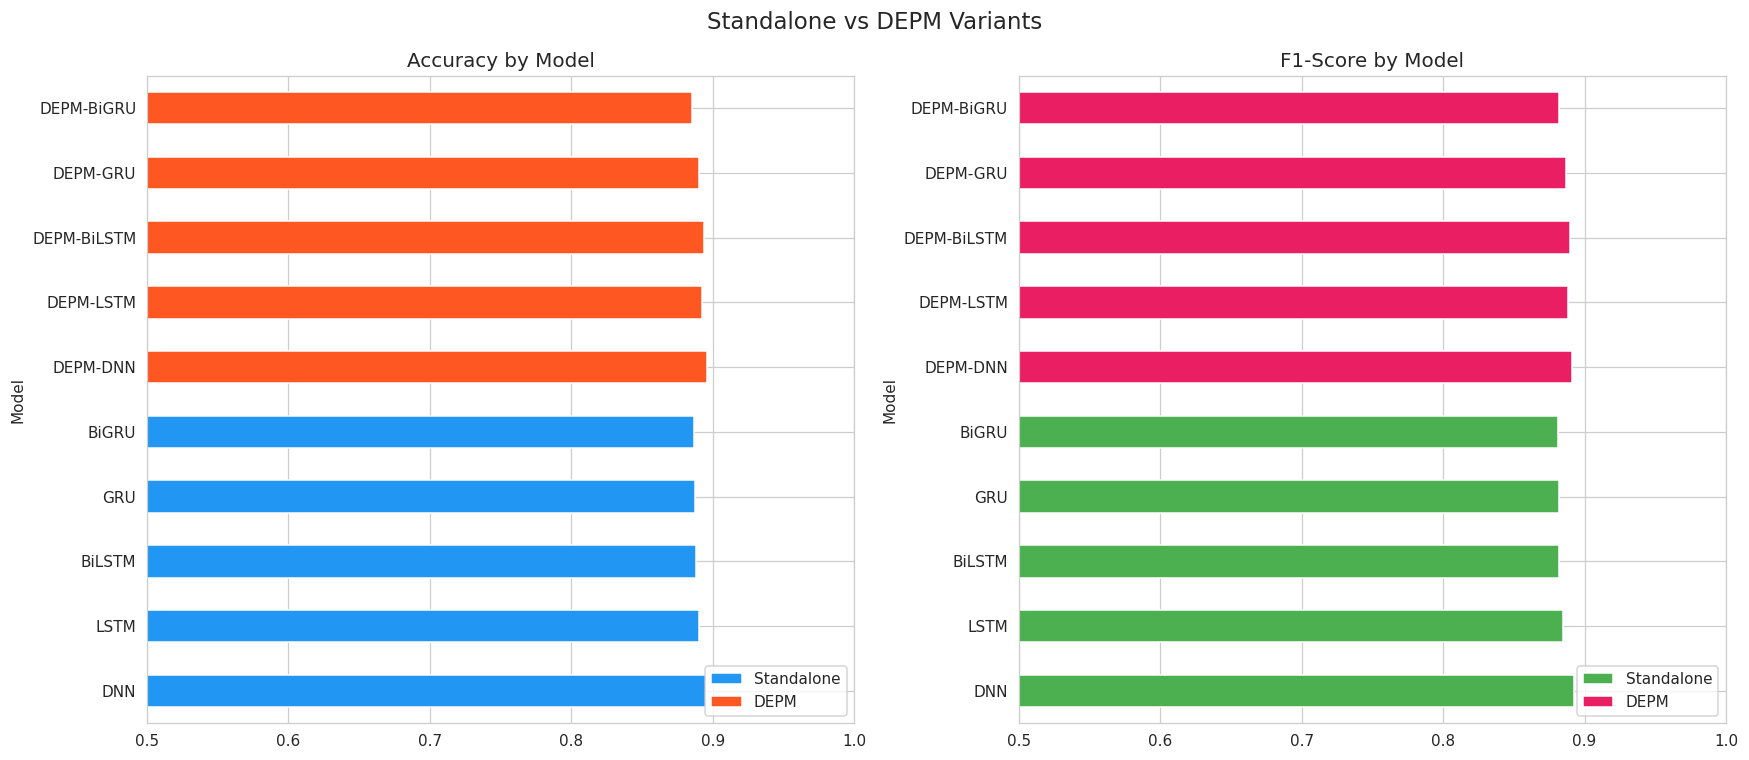

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Accuracy
df_plot = df_res[['Accuracy']].copy()
colors = ['#2196F3']*5 + ['#FF5722']*5
df_plot.plot.barh(ax=axes[0], color=['steelblue'], legend=False)
for i, (idx, row) in enumerate(df_plot.iterrows()):
    axes[0].patches[i].set_facecolor('#2196F3' if i < 5 else '#FF5722')
axes[0].set_title('Accuracy by Model', fontsize=13)
axes[0].set_xlim(0.5, 1.0)

# F1
df_f1 = df_res[['F1-Score']].copy()
df_f1.plot.barh(ax=axes[1], color=['steelblue'], legend=False)
for i, (idx, row) in enumerate(df_f1.iterrows()):
    axes[1].patches[i].set_facecolor('#4CAF50' if i < 5 else '#E91E63')
axes[1].set_title('F1-Score by Model', fontsize=13)
axes[1].set_xlim(0.5, 1.0)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Standalone'), Patch(facecolor='#FF5722', label='DEPM')]
axes[0].legend(handles=legend_elements, loc='lower right')
legend_elements2 = [Patch(facecolor='#4CAF50', label='Standalone'), Patch(facecolor='#E91E63', label='DEPM')]
axes[1].legend(handles=legend_elements2, loc='lower right')

plt.suptitle('Standalone vs DEPM Variants', fontsize=15)
plt.tight_layout(); plt.show()

### 10.2 All Metrics Grouped Bar Chart

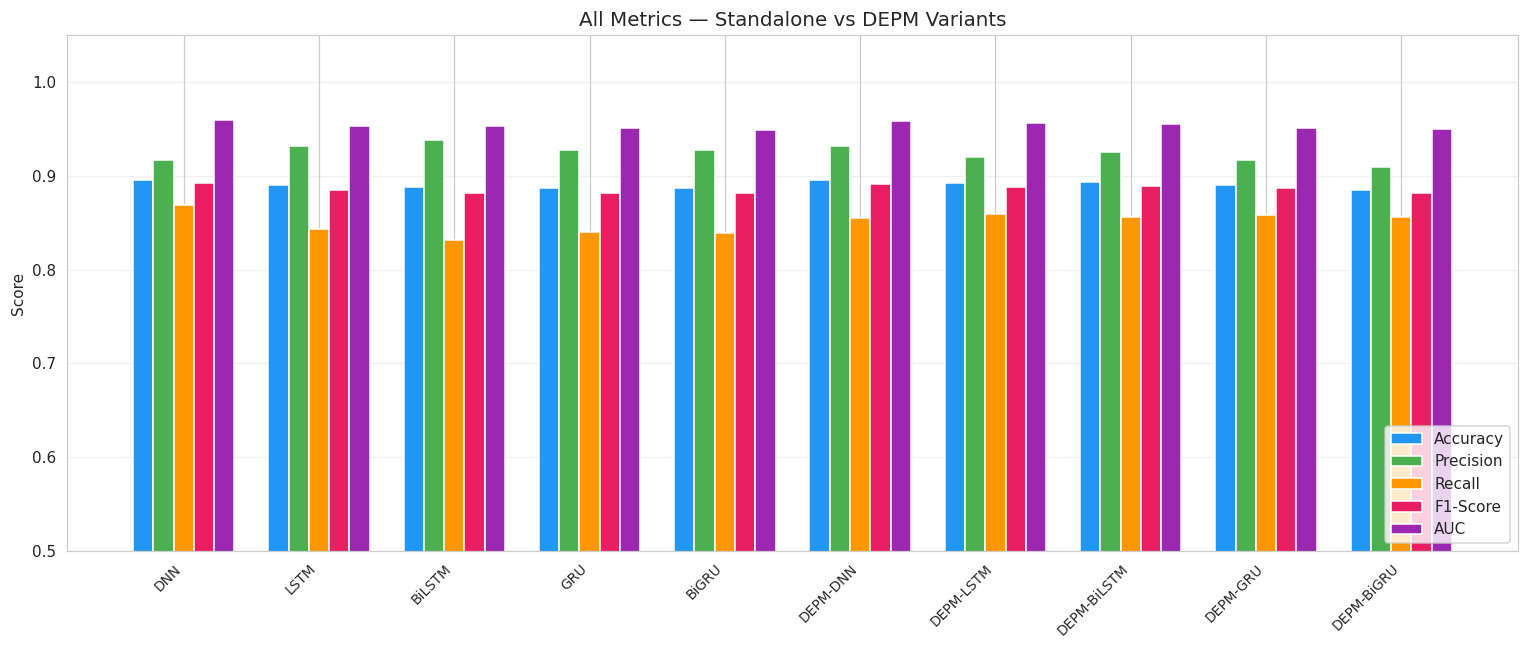

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(df_res))
w = 0.15
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i*w, df_res[metric], w, label=metric, color=colors[i])
ax.set_xticks(x + w*2)
ax.set_xticklabels(df_res.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score'); ax.set_ylim(0.5, 1.05)
ax.set_title('All Metrics — Standalone vs DEPM Variants', fontsize=13)
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### 10.3 Standalone vs DEPM — Paired Comparison

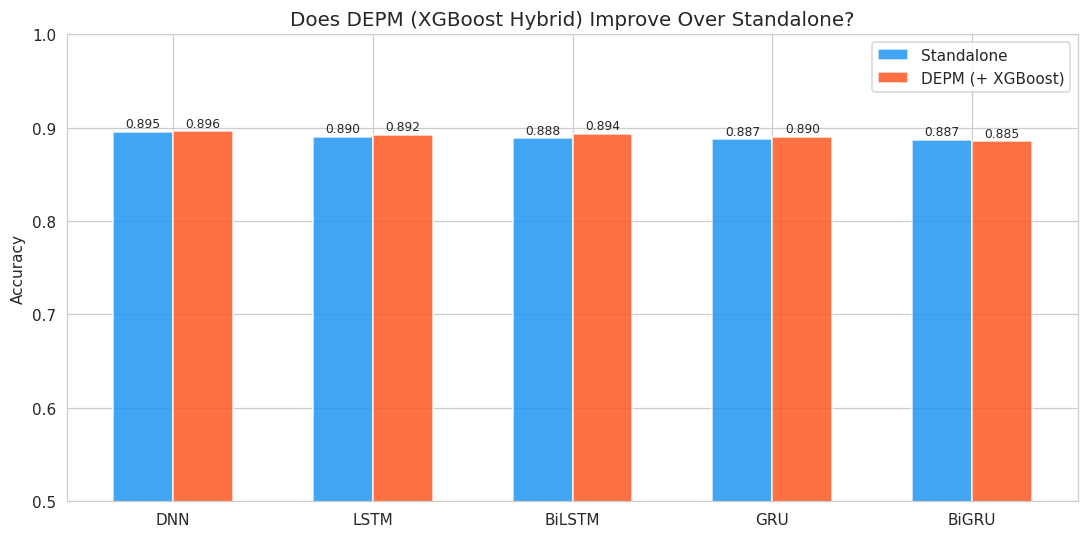

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(arch_names))
w = 0.3
standalone_acc = [standalone_results[n]['Accuracy'] for n in arch_names]
depm_acc = [depm_results[f'DEPM-{n}']['Accuracy'] for n in arch_names]
bars1 = ax.bar(x - w/2, standalone_acc, w, label='Standalone', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + w/2, depm_acc, w, label='DEPM (+ XGBoost)', color='#FF5722', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(arch_names)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.5, 1.0)
ax.set_title('Does DEPM (XGBoost Hybrid) Improve Over Standalone?', fontsize=13)
ax.legend()
for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', fontsize=8)
for b in bars2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

### 10.4 Confusion Matrices

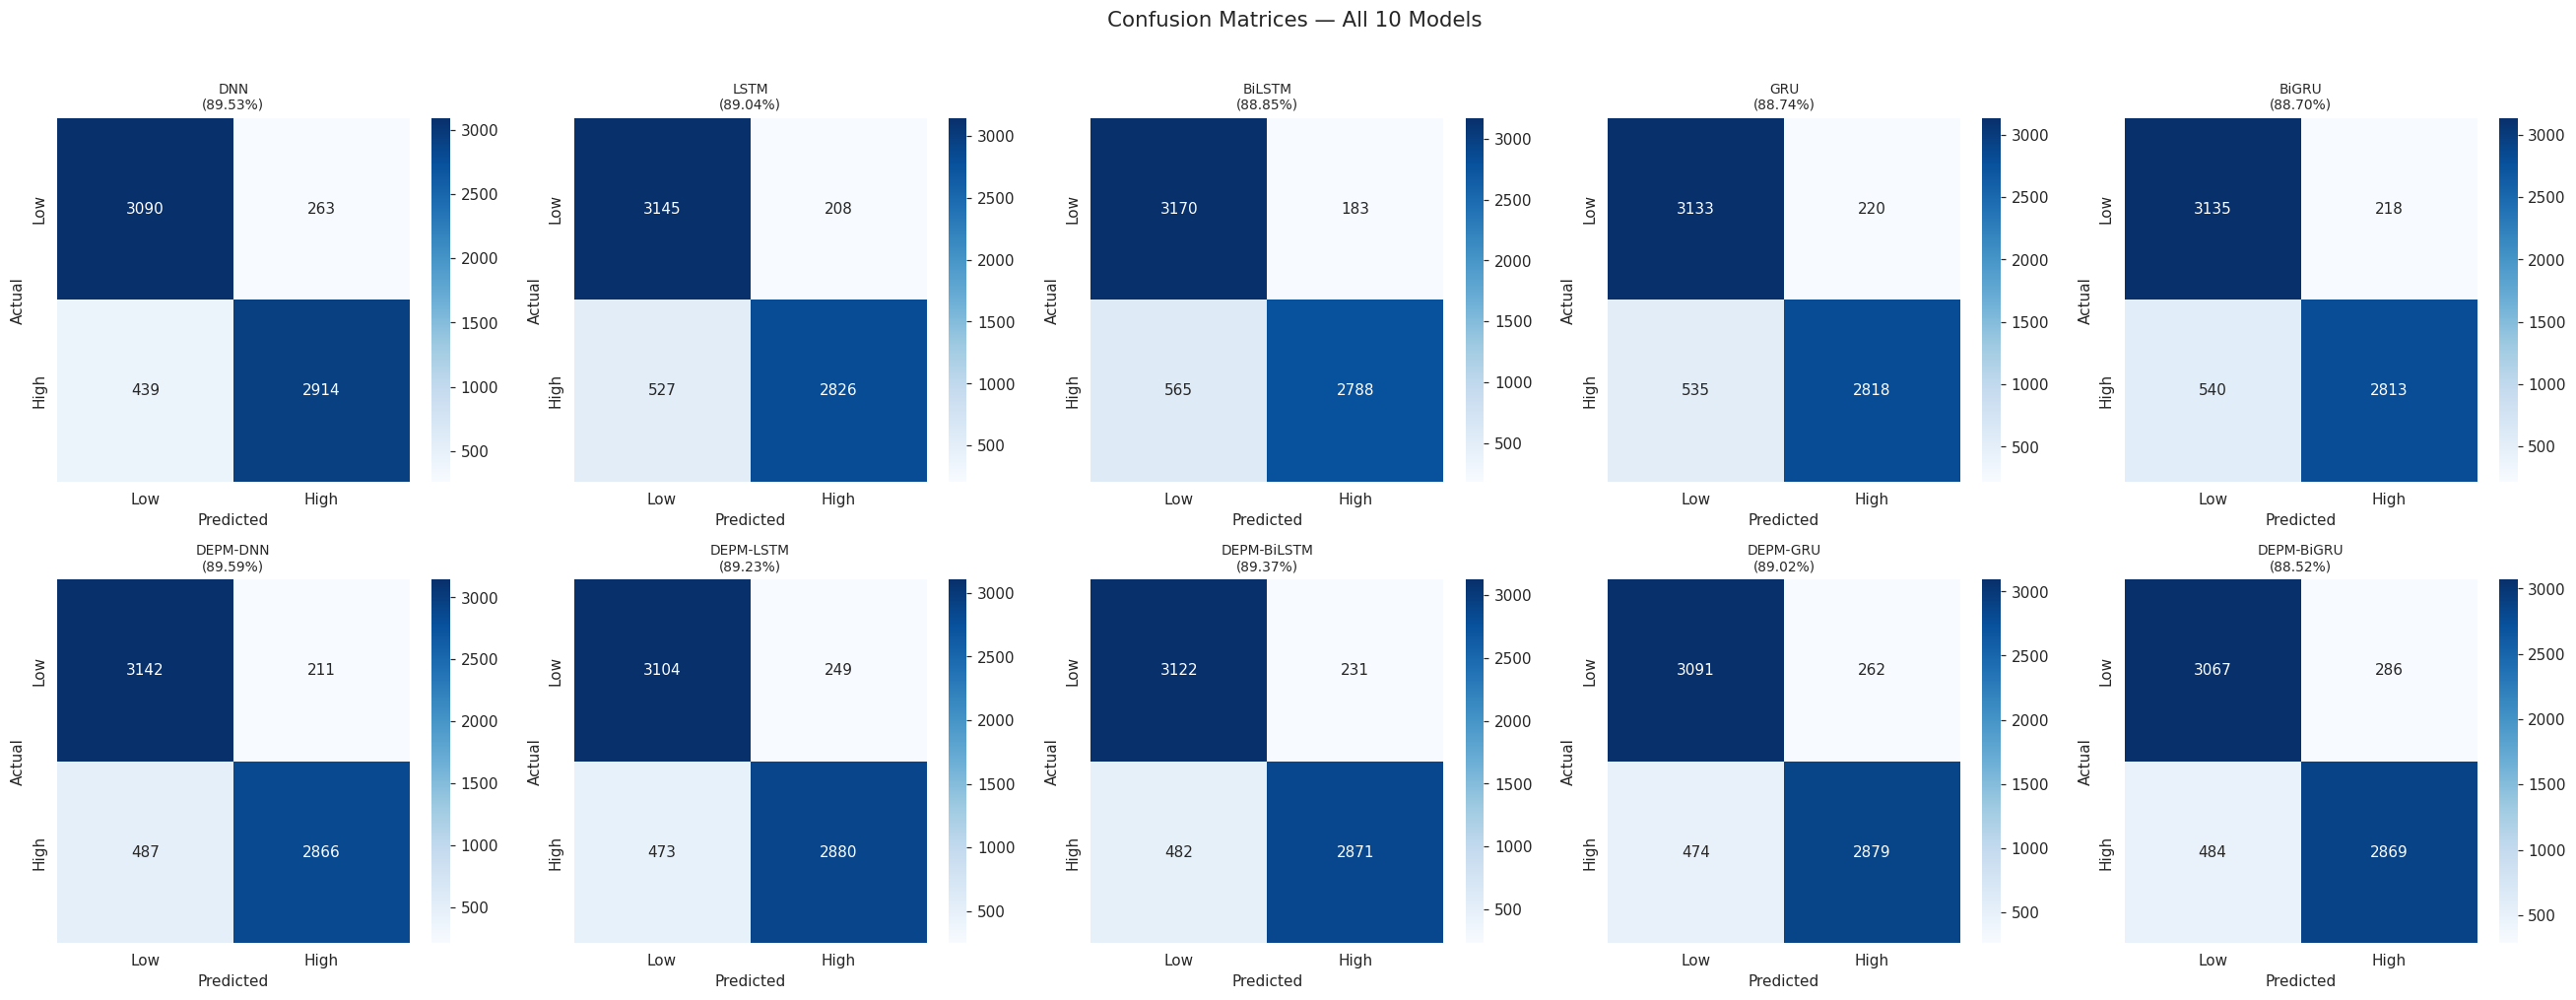

In [13]:
all_preds = {**standalone_preds, **depm_preds}
all_names = list(arch_names) + [f'DEPM-{n}' for n in arch_names]

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
for ax, name in zip(axes.flat, all_names):
    cm = confusion_matrix(y_test, all_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low','High'], yticklabels=['Low','High'])
    acc = accuracy_score(y_test, all_preds[name])
    ax.set_title(f'{name}\n({acc:.2%})', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — All 10 Models', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 10.5 ROC Curves

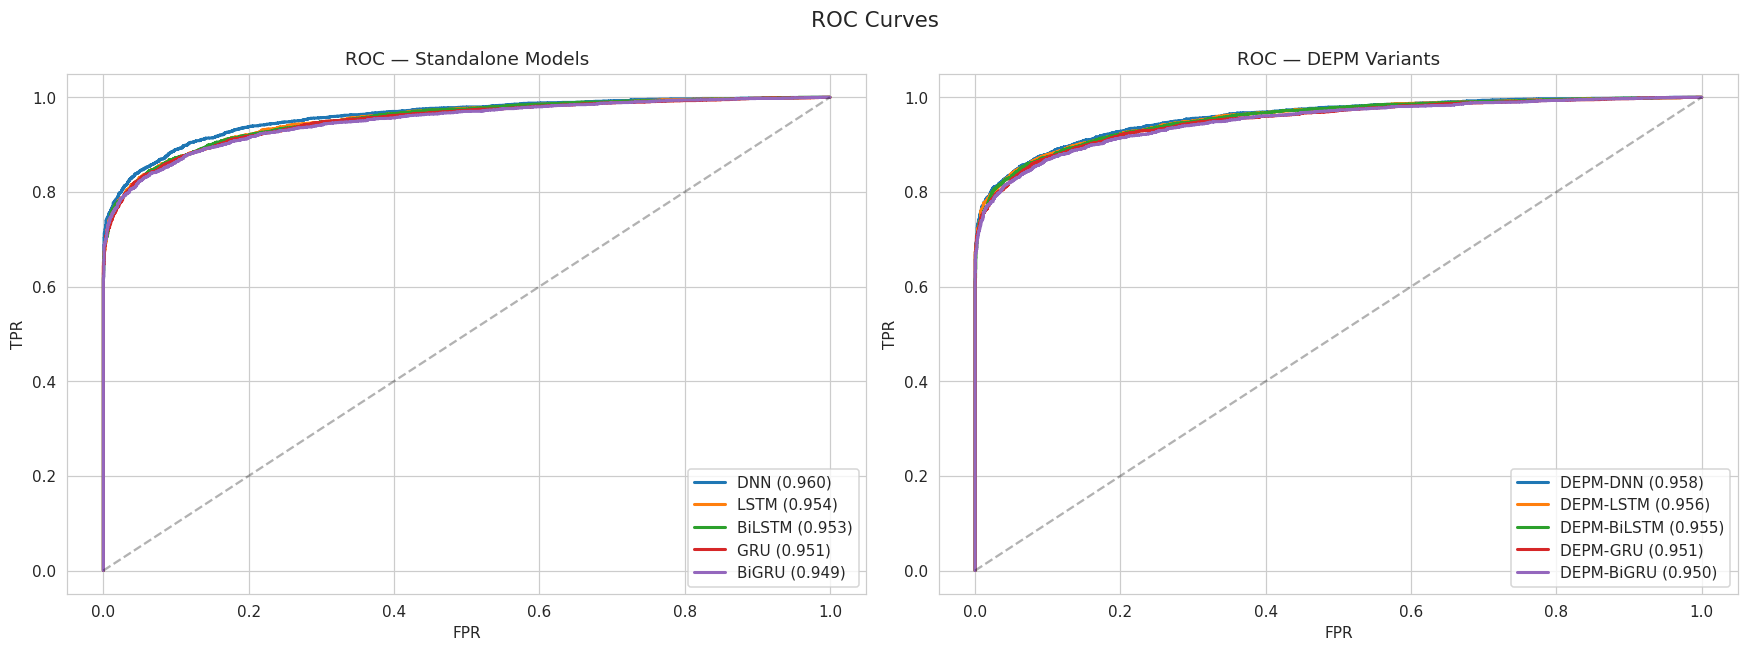

In [14]:
all_probs_dict = {**standalone_probs, **depm_probs}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Standalone
for name in arch_names:
    fpr, tpr, _ = roc_curve(y_test, all_probs_dict[name])
    auc = roc_auc_score(y_test, all_probs_dict[name])
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} ({auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.3)
axes[0].set_title('ROC — Standalone Models'); axes[0].legend(loc='lower right')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')

# DEPM
for name in arch_names:
    dn = f'DEPM-{name}'
    fpr, tpr, _ = roc_curve(y_test, all_probs_dict[dn])
    auc = roc_auc_score(y_test, all_probs_dict[dn])
    axes[1].plot(fpr, tpr, lw=2, label=f'{dn} ({auc:.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.3)
axes[1].set_title('ROC — DEPM Variants'); axes[1].legend(loc='lower right')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
plt.suptitle('ROC Curves', fontsize=14)
plt.tight_layout(); plt.show()

### 10.6 Classification Reports

In [15]:
for name in all_names:
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, all_preds[name], target_names=['Low','High']))


  DNN
              precision    recall  f1-score   support

         Low       0.88      0.92      0.90      3353
        High       0.92      0.87      0.89      3353

    accuracy                           0.90      6706
   macro avg       0.90      0.90      0.90      6706
weighted avg       0.90      0.90      0.90      6706


  LSTM
              precision    recall  f1-score   support

         Low       0.86      0.94      0.90      3353
        High       0.93      0.84      0.88      3353

    accuracy                           0.89      6706
   macro avg       0.89      0.89      0.89      6706
weighted avg       0.89      0.89      0.89      6706


  BiLSTM
              precision    recall  f1-score   support

         Low       0.85      0.95      0.89      3353
        High       0.94      0.83      0.88      3353

    accuracy                           0.89      6706
   macro avg       0.89      0.89      0.89      6706
weighted avg       0.89      0.89      0.89      

## 11. Save Summary

In [16]:
# Save results table
df_res.to_csv(f'{SAVE_DIR}/results.csv')
print(f"Results saved to {SAVE_DIR}/results.csv")
print()
print("="*60)
print("  SAVED ARTIFACTS")
print("="*60)
print()
for f_name in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, f_name)
    size = os.path.getsize(fpath)
    print(f"  {f_name:40s} {size/1024:.1f} KB")
print()
print("These files can be loaded in FastAPI for inference.")
print("Architecture classes (DNN, RNNModel, CascadedResNet) must be")
print("defined in the FastAPI app to load the PyTorch models.")

Results saved to /kaggle/working/models/results.csv

  SAVED ARTIFACTS

  config.json                              0.2 KB
  depm_bigru_dl.pt                         1684.6 KB
  depm_bigru_xgb.pkl                       3315.0 KB
  depm_bilstm_dl.pt                        2201.6 KB
  depm_bilstm_xgb.pkl                      3283.5 KB
  depm_dnn_dl.pt                           233.6 KB
  depm_dnn_xgb.pkl                         3119.3 KB
  depm_gru_dl.pt                           652.3 KB
  depm_gru_xgb.pkl                         3297.3 KB
  depm_lstm_dl.pt                          846.8 KB
  depm_lstm_xgb.pkl                        3265.0 KB
  pca.pkl                                  2.5 KB
  resnet.pt                                573.4 KB
  results.csv                              1.1 KB
  scaler.pkl                               0.9 KB
  standalone_bigru.pt                      1684.6 KB
  standalone_bilstm.pt                     2201.6 KB
  standalone_dnn.pt                        